# 🔐 IoT Network Intrusion Detection System — Advanced ML Pipeline
**Final Year Project | Advanced Version**

### Enhancements Over Baseline:
- ✅ Robust preprocessing pipeline with SMOTE class balancing
- ✅ Feature selection using mutual information & variance thresholding
- ✅ Multi-model comparison: SVM, Random Forest, XGBoost, LightGBM, MLP
- ✅ Stratified K-Fold cross-validation
- ✅ Bayesian hyperparameter optimization (Optuna)
- ✅ SHAP explainability (feature importance & force plots)
- ✅ Advanced metrics: MCC, Cohen's Kappa, F1-macro
- ✅ Full evaluation dashboard: ROC-AUC, PR curves, confusion matrix
- ✅ Sklearn Pipeline to prevent data leakage

In [1]:
!pip install xgboost
!pip install lightgbm shap optuna imbalanced-learn


## 1. Install & Import Libraries

In [2]:
# Install extra packages if needed
# !pip install xgboost lightgbm shap optuna imbalanced-learn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.feature_selection import SelectKBest, mutual_info_classif, VarianceThreshold

# Sampling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Validation & Metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, f1_score
)

# Explainability
import shap

# Hyperparameter Optimization
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Plotting style
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120
print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


## 2. Load & Explore Dataset

In [3]:
df = pd.read_csv('iot23_combined.csv')
print(f'📦 Dataset shape: {df.shape}')
df.head()

📦 Dataset shape: (1048575, 26)


,Unnamed: 0,duration,orig_bytes,resp_bytes,missed_bytes,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,label,...,conn_state_RSTOS0,conn_state_RSTR,conn_state_RSTRH,conn_state_S0,conn_state_S1,conn_state_S2,conn_state_S3,conn_state_SF,conn_state_SH,conn_state_SHR
0,0,2.998796,0,0,0,3,180,0,0,PartOfAHorizontalPortScan,...,0,0,0,1,0,0,0,0,0,0
1,1,0.000000,0,0,0,1,60,0,0,PartOfAHorizontalPortScan,...,0,0,0,1,0,0,0,0,0,0
2,2,0.000000,0,0,0,1,60,0,0,PartOfAHorizontalPortScan,...,0,0,0,1,0,0,0,0,0,0
3,3,2.998804,0,0,0,3,180,0,0,Benign,...,0,0,0,1,0,0,0,0,0,0
4,4,0.000000,0,0,0,1,60,0,0,Benign,...,0,0,0,1,0,0,0,0,0,0


In [4]:
# Detailed dataset info
print('='*60)
print('DATASET OVERVIEW')
print('='*60)
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print()
print('🏷️  Class Distribution:')
print(df['label'].value_counts())
print()
print('❓ Missing Values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

DATASET OVERVIEW
Rows: 1,048,575  |  Columns: 26
Memory usage: 279.31 MB

🏷️  Class Distribution:
label
PartOfAHorizontalPortScan     641329
Benign                        193854
Okiru                         163016
DDoS                           39354
C&C                             6878
Attack                          3915
C&C-HeartBeat                    134
C&C-FileDownload                  43
C&C-Torii                         30
FileDownload                      13
C&C-HeartBeat-FileDownload         8
C&C-Mirai                          1
Name: count, dtype: int64

❓ Missing Values:
Series([], dtype: int64)


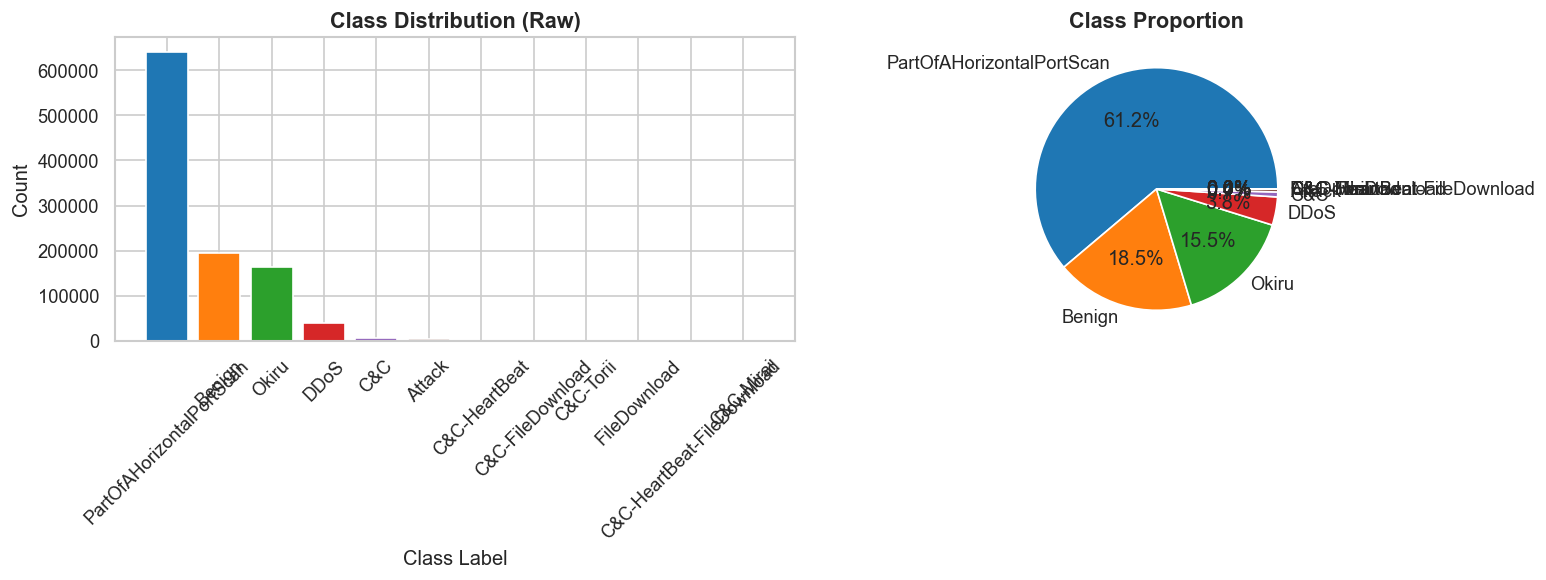

In [5]:
# Class distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['label'].value_counts()
axes[0].bar(class_counts.index.astype(str), class_counts.values, color=sns.color_palette('tab10', len(class_counts)))
axes[0].set_title('Class Distribution (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(class_counts.values, labels=class_counts.index.astype(str),
            autopct='%1.1f%%', colors=sns.color_palette('tab10', len(class_counts)))
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Advanced Preprocessing Pipeline

In [6]:
# Stratified sample to preserve class ratios
df_sample = df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), int(15000 * len(x) / len(df))), random_state=42)
).reset_index(drop=True)

print(f'Sampled shape: {df_sample.shape}')
print('Sampled class distribution:')
print(df_sample['label'].value_counts())

# Remove classes with too few samples
min_class_samples = 6
class_counts = df_sample['label'].value_counts()
valid_classes = class_counts[class_counts >= min_class_samples].index
df_sample = df_sample[df_sample['label'].isin(valid_classes)]
print(f'Samples after removing rare classes: {df_sample.shape[0]}')

Sampled shape: (14995, 26)
Sampled class distribution:
label
PartOfAHorizontalPortScan    9174
Benign                       2773
Okiru                        2331
DDoS                          562
C&C                            98
Attack                         56
C&C-HeartBeat                   1
Name: count, dtype: int64
Samples after removing rare classes: 14994


In [7]:
# Encode categorical columns
label_encoders = {}
for col in df_sample.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_sample[col] = le.fit_transform(df_sample[col].astype(str))
    label_encoders[col] = le

# Handle missing values
df_sample.fillna(df_sample.median(numeric_only=True), inplace=True)

# Remove constant/near-zero variance features
selector = VarianceThreshold(threshold=0.01)
X_raw = df_sample.drop('label', axis=1)
y = df_sample['label']

X_var = pd.DataFrame(selector.fit_transform(X_raw), columns=X_raw.columns[selector.get_support()])
print(f'Features after variance threshold: {X_var.shape[1]} (removed {X_raw.shape[1] - X_var.shape[1]})')

Features after variance threshold: 13 (removed 12)



🎯 Top 13 features selected by Mutual Information:
       Feature  MI Score
 orig_ip_bytes  0.341874
      duration  0.251193
     orig_pkts  0.235398
    orig_bytes  0.152764
    resp_bytes  0.143728
     proto_tcp  0.096771
     proto_udp  0.094649
 conn_state_S0  0.055415
     resp_pkts  0.051597
    Unnamed: 0  0.049638
 resp_ip_bytes  0.048335
conn_state_OTH  0.037493
 conn_state_SF  0.023678


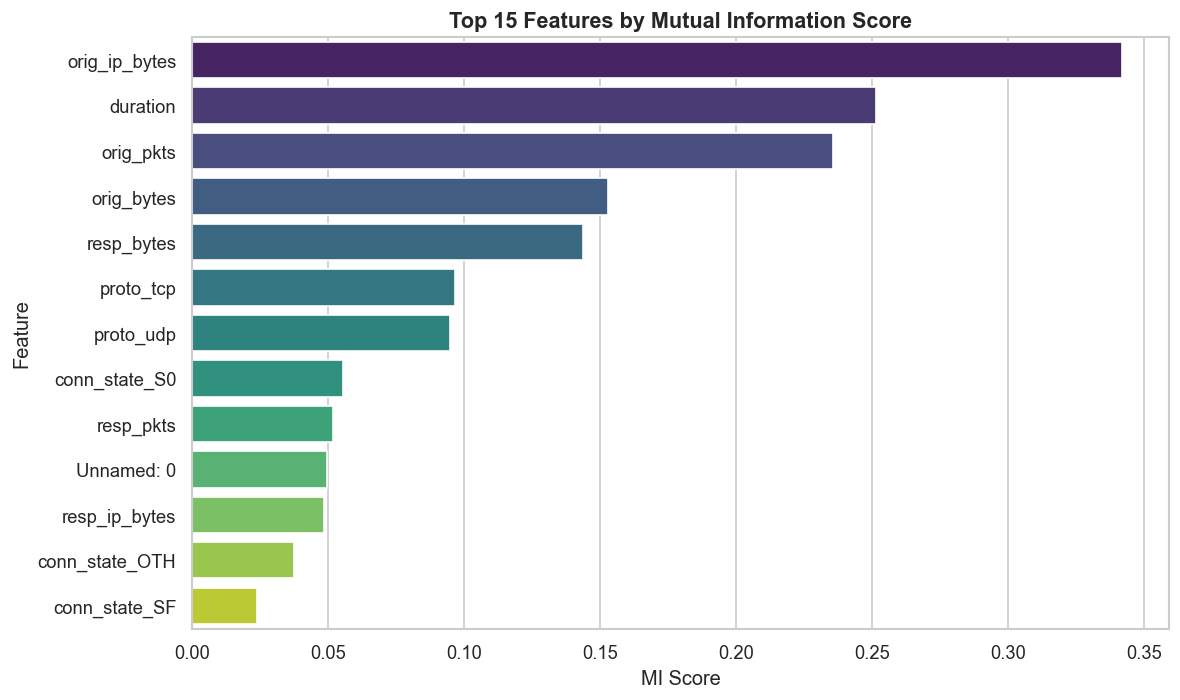

In [8]:
# Feature selection using Mutual Information
k_best = min(20, X_var.shape[1])  # Select top 20 features
mi_selector = SelectKBest(mutual_info_classif, k=k_best)
X_selected = mi_selector.fit_transform(X_var, y)
selected_features = X_var.columns[mi_selector.get_support()].tolist()

print(f'\n🎯 Top {k_best} features selected by Mutual Information:')
mi_scores = mi_selector.scores_[mi_selector.get_support()]
feat_importance_df = pd.DataFrame({'Feature': selected_features, 'MI Score': mi_scores})\
                       .sort_values('MI Score', ascending=False)
print(feat_importance_df.to_string(index=False))

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance_df.head(15), x='MI Score', y='Feature', palette='viridis')
plt.title('Top 15 Features by Mutual Information Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# ─── Train/Test Split & Feature Scaling ───────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {X_train_scaled.shape[0]:,}")
print(f"Test samples     : {X_test_scaled.shape[0]:,}")
print(f"Features         : {X_train_scaled.shape[1]}")
print("✅ Train/test split and scaling complete")


Training samples : 11,995
Test samples     : 2,999
Features         : 13
✅ Train/test split and scaling complete


In [10]:
from collections import Counter
from imblearn.over_sampling import SMOTE, RandomOverSampler

# Check class distribution
counter = Counter(y_train)
print("Class distribution before resampling:", counter)

min_samples = min(counter.values())

# Choose sampling method safely
if min_samples < 3:
    print("⚠️ Using RandomOverSampler (too few samples for SMOTE)")
    sampler = RandomOverSampler(random_state=42)
else:
    k = min(3, min_samples - 1)
    print(f"✅ Using SMOTE with k_neighbors={k}")
    sampler = SMOTE(random_state=42, k_neighbors=k)

# Apply sampling
X_train_bal, y_train_bal = sampler.fit_resample(X_train_scaled, y_train)

print(f'\nTraining set before sampling: {X_train_scaled.shape[0]:,} samples')
print(f'Training set after sampling:  {X_train_bal.shape[0]:,} samples')
print(f'Test set: {X_test_scaled.shape[0]:,} samples')

Class distribution before resampling: Counter({5: 7339, 1: 2218, 4: 1865, 3: 450, 2: 78, 0: 45})
✅ Using SMOTE with k_neighbors=3

Training set before sampling: 11,995 samples
Training set after sampling:  44,034 samples
Test set: 2,999 samples


## 4. Hyperparameter Optimization with Optuna

In [11]:
# Optimize XGBoost (fastest model for tuning demo)
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'use_label_encoder': False,
        'eval_metric': 'mlogloss',
        'random_state': 42,
        'n_jobs': -1
    }
    model = xgb.XGBClassifier(**params)
    score = cross_val_score(model, X_train_bal, y_train_bal,
                            cv=3, scoring='f1_macro', n_jobs=-1).mean()
    return score

print('🔍 Running Optuna hyperparameter search for XGBoost...')
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

best_xgb_params = study.best_params
best_xgb_params.update({'use_label_encoder': False, 'eval_metric': 'mlogloss',
                         'random_state': 42, 'n_jobs': -1})
print(f'\n✅ Best XGBoost params: {best_xgb_params}')
print(f'Best CV F1-macro: {study.best_value:.4f}')

🔍 Running Optuna hyperparameter search for XGBoost...


  0%|          | 0/20 [00:00<?, ?it/s]


✅ Best XGBoost params: {'n_estimators': 482, 'max_depth': 10, 'learning_rate': 0.216874599764822, 'subsample': 0.7380385927179427, 'colsample_bytree': 0.9573787962207346, 'use_label_encoder': False, 'eval_metric': 'mlogloss', 'random_state': 42, 'n_jobs': -1}
Best CV F1-macro: 0.8300


## 5. Multi-Model Training & Comparison

In [12]:
models = {
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),

    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10,
        random_state=42, n_jobs=-1
    ),

    'XGBoost (Tuned)': xgb.XGBClassifier(**best_xgb_params),

    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, num_leaves=63,
        random_state=42, n_jobs=-1, verbose=-1
    ),

    'MLP Neural Net': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu', max_iter=200,
        early_stopping=True, random_state=42
    ),

    'AdaBoost': AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    )
}

results = {}
trained_models = {}

print('🚀 Training all models...\n')
print(f'{"Model":<22} {"Accuracy":>10} {"F1-Macro":>10} {"MCC":>10} {"Kappa":>10} {"Time(s)":>10}')
print('-' * 75)

for name, model in models.items():
    start = time.time()
    model.fit(X_train_bal, y_train_bal)
    elapsed = time.time() - start
    
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    
    results[name] = {'accuracy': acc, 'f1_macro': f1, 'mcc': mcc, 'kappa': kappa,
                     'time': elapsed, 'y_pred': y_pred, 'model': model}
    trained_models[name] = model
    
    print(f'{name:<22} {acc:>10.4f} {f1:>10.4f} {mcc:>10.4f} {kappa:>10.4f} {elapsed:>10.2f}')

print()
best_model_name = max(results, key=lambda k: results[k]['f1_macro'])
print(f'🏆 Best Model: {best_model_name} (F1-Macro: {results[best_model_name]["f1_macro"]:.4f})')

🚀 Training all models...

Model                    Accuracy   F1-Macro        MCC      Kappa    Time(s)
---------------------------------------------------------------------------
SVM (RBF)                  0.4311     0.4479     0.2610     0.2227     427.58
Random Forest              0.5258     0.5471     0.4565     0.3845       1.24
XGBoost (Tuned)            0.5805     0.5902     0.4704     0.4185      14.13
LightGBM                   0.5712     0.5798     0.4583     0.4065      10.19
MLP Neural Net             0.4515     0.5089     0.3976     0.3186      59.11
AdaBoost                   0.4288     0.4671     0.3647     0.2937       3.32

🏆 Best Model: XGBoost (Tuned) (F1-Macro: 0.5902)


## 6. Stratified K-Fold Cross-Validation

📊 Running 5-Fold Stratified Cross-Validation...

Random Forest          CV F1: 0.8021 ± 0.0047  |  Scores: [0.8106 0.7967 0.7994 0.8006 0.8032]
XGBoost (Tuned)        CV F1: 0.8308 ± 0.0056  |  Scores: [0.8392 0.8259 0.8253 0.8279 0.8355]
LightGBM               CV F1: 0.8289 ± 0.0030  |  Scores: [0.8337 0.8259 0.8273 0.8265 0.8313]
MLP Neural Net         CV F1: 0.7775 ± 0.0047  |  Scores: [0.7843 0.7704 0.7799 0.7746 0.7781]
AdaBoost               CV F1: 0.6840 ± 0.0135  |  Scores: [0.6826 0.6932 0.6918 0.6942 0.6584]


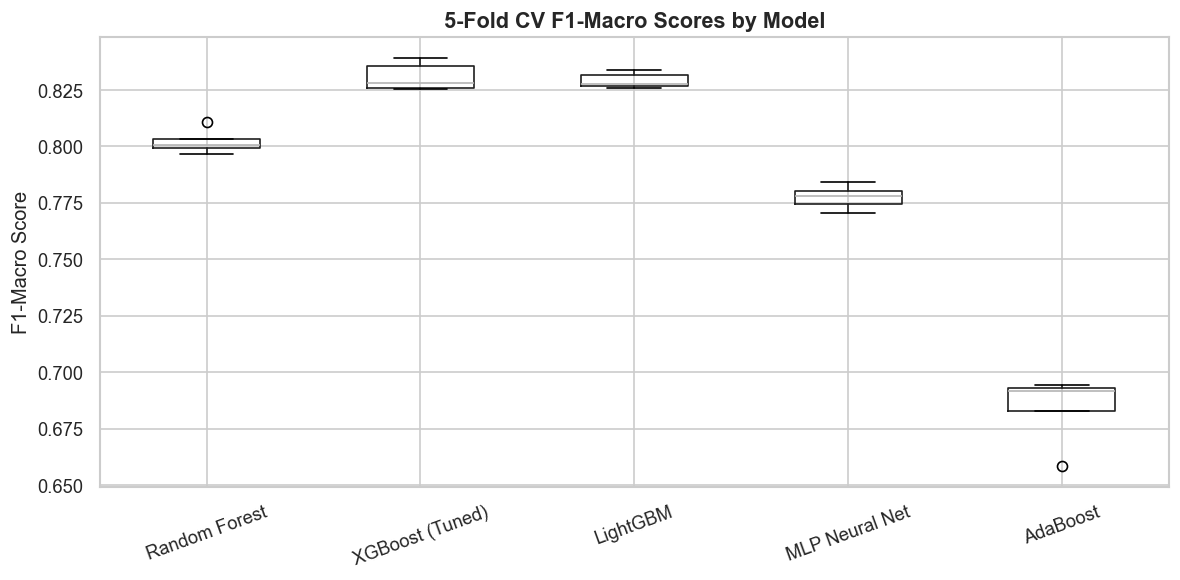

In [13]:
print('📊 Running 5-Fold Stratified Cross-Validation...\n')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
# Use top 3 fastest models for CV
cv_models = {k: v for k, v in list(models.items())[1:]}  # skip SVM (slow)

for name, model in cv_models.items():
    scores = cross_val_score(model, X_train_bal, y_train_bal,
                              cv=skf, scoring='f1_macro', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<22} CV F1: {scores.mean():.4f} ± {scores.std():.4f}  |  Scores: {np.round(scores, 4)}')

# Visualize CV results
plt.figure(figsize=(10, 5))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(figsize=(10, 5))
plt.title('5-Fold CV F1-Macro Scores by Model', fontsize=13, fontweight='bold')
plt.ylabel('F1-Macro Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 7. Detailed Evaluation — Best Model

In [14]:
best_model = trained_models[best_model_name]
y_pred_best = results[best_model_name]['y_pred']

print(f'📋 Classification Report — {best_model_name}\n')
print(classification_report(y_test, y_pred_best, zero_division=0))

📋 Classification Report — XGBoost (Tuned)

              precision    recall  f1-score   support

           0       0.79      1.00      0.88        11
           1       0.74      0.77      0.75       555
           2       0.30      0.90      0.45        20
           3       0.24      0.79      0.37       112
           4       0.35      0.82      0.49       466
           5       0.91      0.44      0.60      1835

    accuracy                           0.58      2999
   macro avg       0.56      0.79      0.59      2999
weighted avg       0.76      0.58      0.60      2999



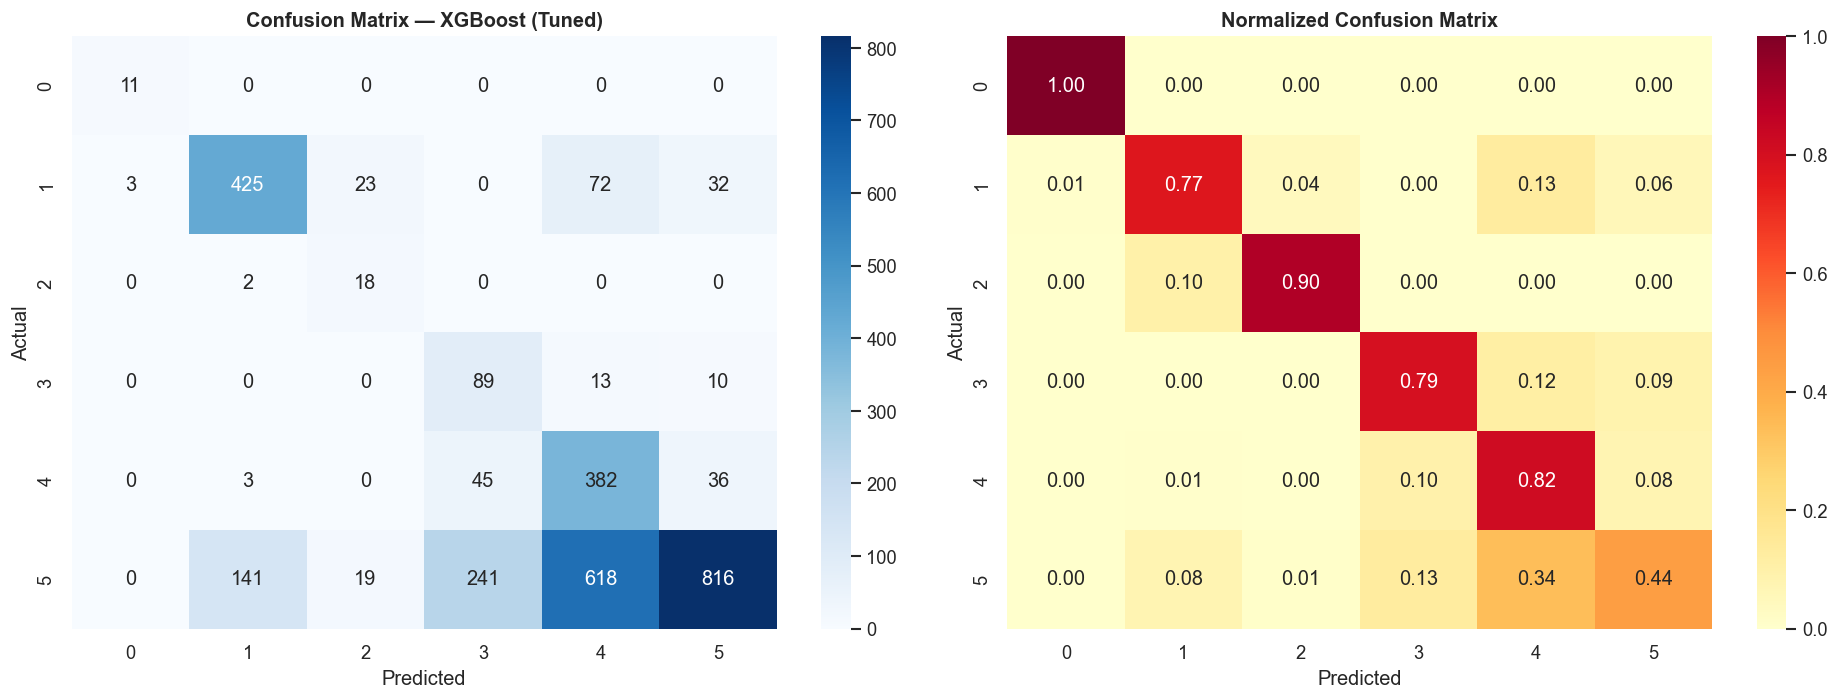

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Normalized Confusion Matrix', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 8. ROC-AUC & Precision-Recall Curves

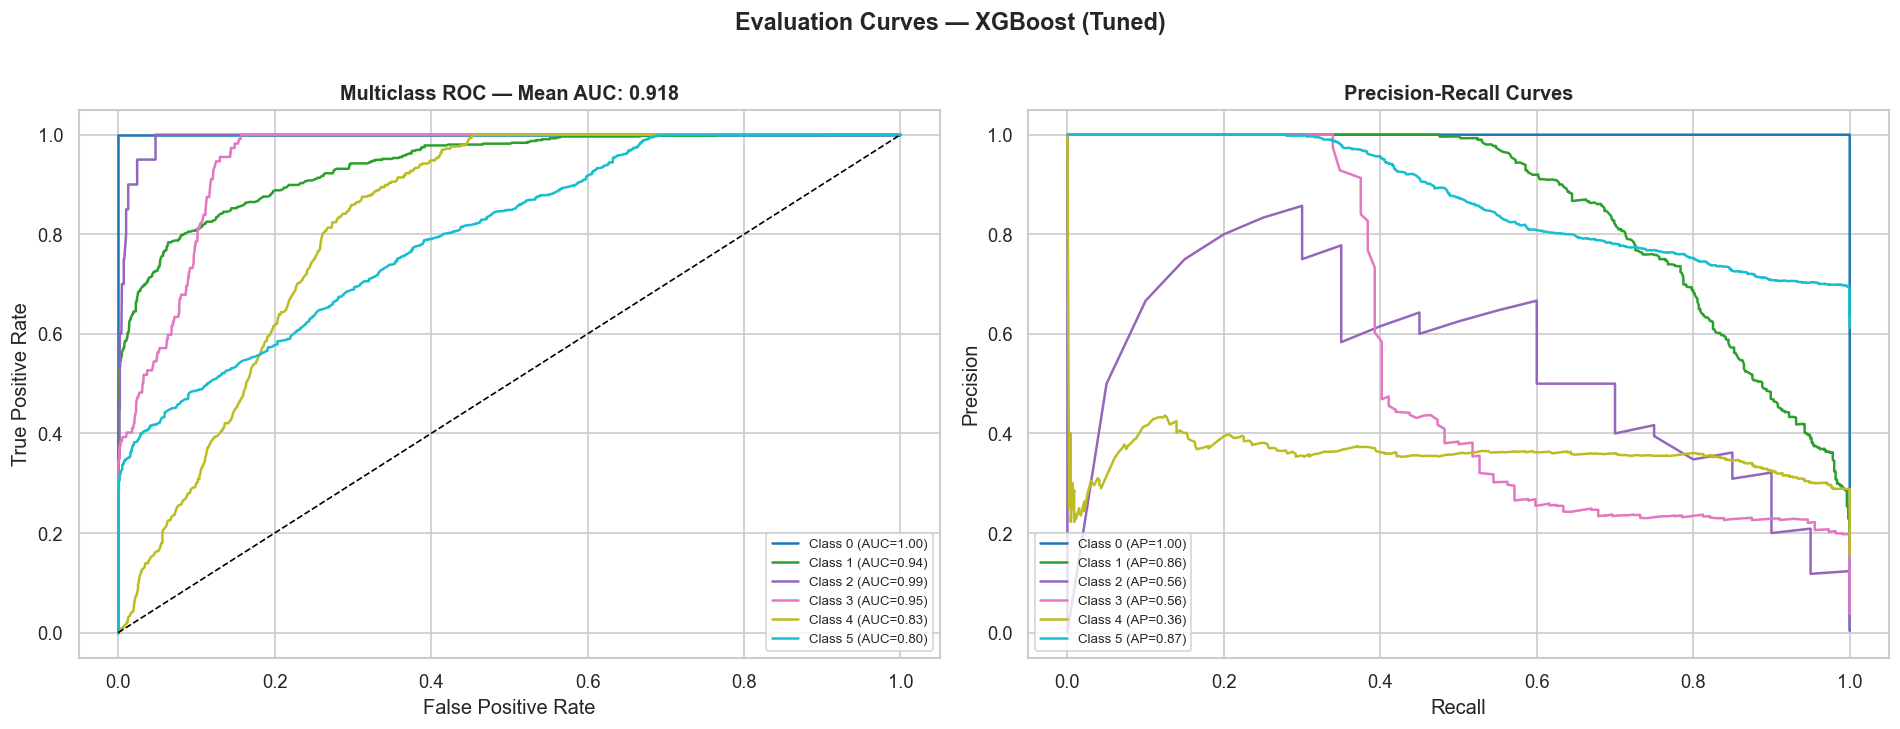

In [16]:
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# Get probability scores
if hasattr(best_model, 'predict_proba'):
    y_score = best_model.predict_proba(X_test_scaled)
else:
    y_score = best_model.decision_function(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

# ROC curves
mean_auc = 0
for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc_val = auc(fpr, tpr)
    mean_auc += roc_auc_val
    axes[0].plot(fpr, tpr, color=color, lw=1.5, label=f'Class {cls} (AUC={roc_auc_val:.2f})')

axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'Multiclass ROC — Mean AUC: {mean_auc/len(classes):.3f}', fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right')

# Precision-Recall curves
for i, (cls, color) in enumerate(zip(classes, colors)):
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_score[:, i])
    axes[1].plot(rec, prec, color=color, lw=1.5, label=f'Class {cls} (AP={ap:.2f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend(fontsize=8, loc='lower left')

plt.suptitle(f'Evaluation Curves — {best_model_name}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Model Performance Comparison Dashboard

          Model  Accuracy  F1-Macro    MCC  Cohen's Kappa  Training Time (s)
XGBoost (Tuned)    0.5805    0.5902 0.4704         0.4185            14.1253
       LightGBM    0.5712    0.5798 0.4583         0.4065            10.1917
  Random Forest    0.5258    0.5471 0.4565         0.3845             1.2421
 MLP Neural Net    0.4515    0.5089 0.3976         0.3186            59.1065
       AdaBoost    0.4288    0.4671 0.3647         0.2937             3.3170
      SVM (RBF)    0.4311    0.4479 0.2610         0.2227           427.5800


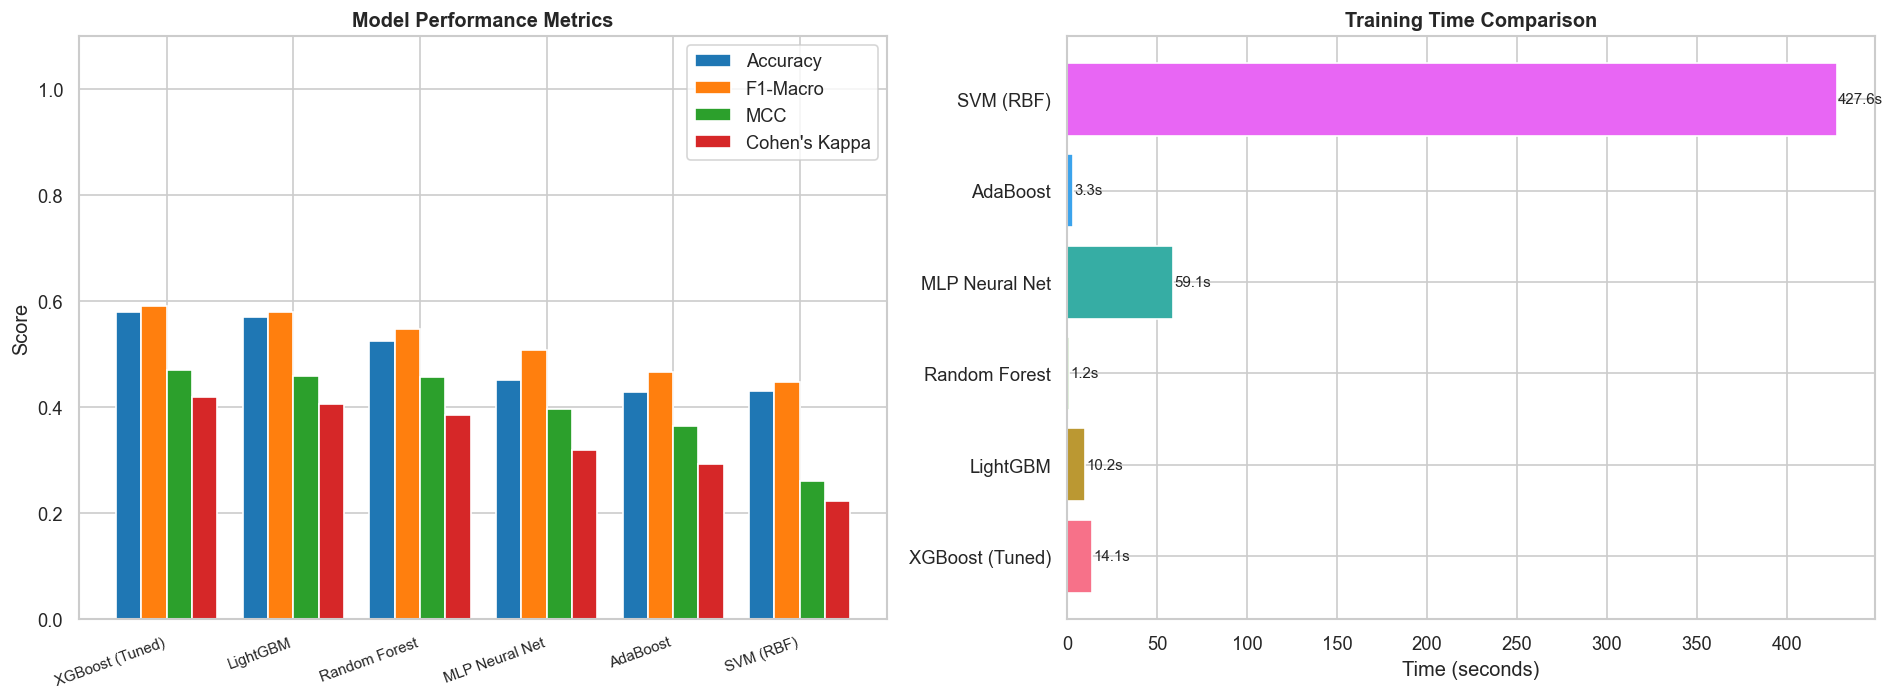

In [17]:
metrics_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results],
    'F1-Macro': [results[m]['f1_macro'] for m in results],
    'MCC': [results[m]['mcc'] for m in results],
    "Cohen's Kappa": [results[m]['kappa'] for m in results],
    'Training Time (s)': [results[m]['time'] for m in results]
}).sort_values('F1-Macro', ascending=False)

print(metrics_df.round(4).to_string(index=False))

# Dashboard
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart for metrics
metric_cols = ['Accuracy', 'F1-Macro', 'MCC', "Cohen's Kappa"]
x = np.arange(len(metrics_df))
width = 0.2
for j, metric in enumerate(metric_cols):
    axes[0].bar(x + j*width, metrics_df[metric], width, label=metric)
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(metrics_df['Model'], rotation=20, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Model Performance Metrics', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Score')

# Training time comparison
colors_bar = sns.color_palette('husl', len(metrics_df))
axes[1].barh(metrics_df['Model'], metrics_df['Training Time (s)'], color=colors_bar)
axes[1].set_title('Training Time Comparison', fontweight='bold')
axes[1].set_xlabel('Time (seconds)')
for i, v in enumerate(metrics_df['Training Time (s)']):
    axes[1].text(v + 0.5, i, f'{v:.1f}s', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 10. SHAP Explainability Analysis

In [18]:
print('🔍 Computing SHAP values for best model...')

# Use a tree-based model for SHAP (faster)
shap_model_name = 'XGBoost (Tuned)' if 'XGBoost (Tuned)' in trained_models else 'Random Forest'
shap_model = trained_models[shap_model_name]

# Use a sample for SHAP computation (full set can be slow)
X_test_df = pd.DataFrame(X_test_scaled[:500], columns=selected_features)

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test_df)

print(f'SHAP computed using: {shap_model_name}')

🔍 Computing SHAP values for best model...
SHAP computed using: XGBoost (Tuned)


<Figure size 1200x840 with 0 Axes>

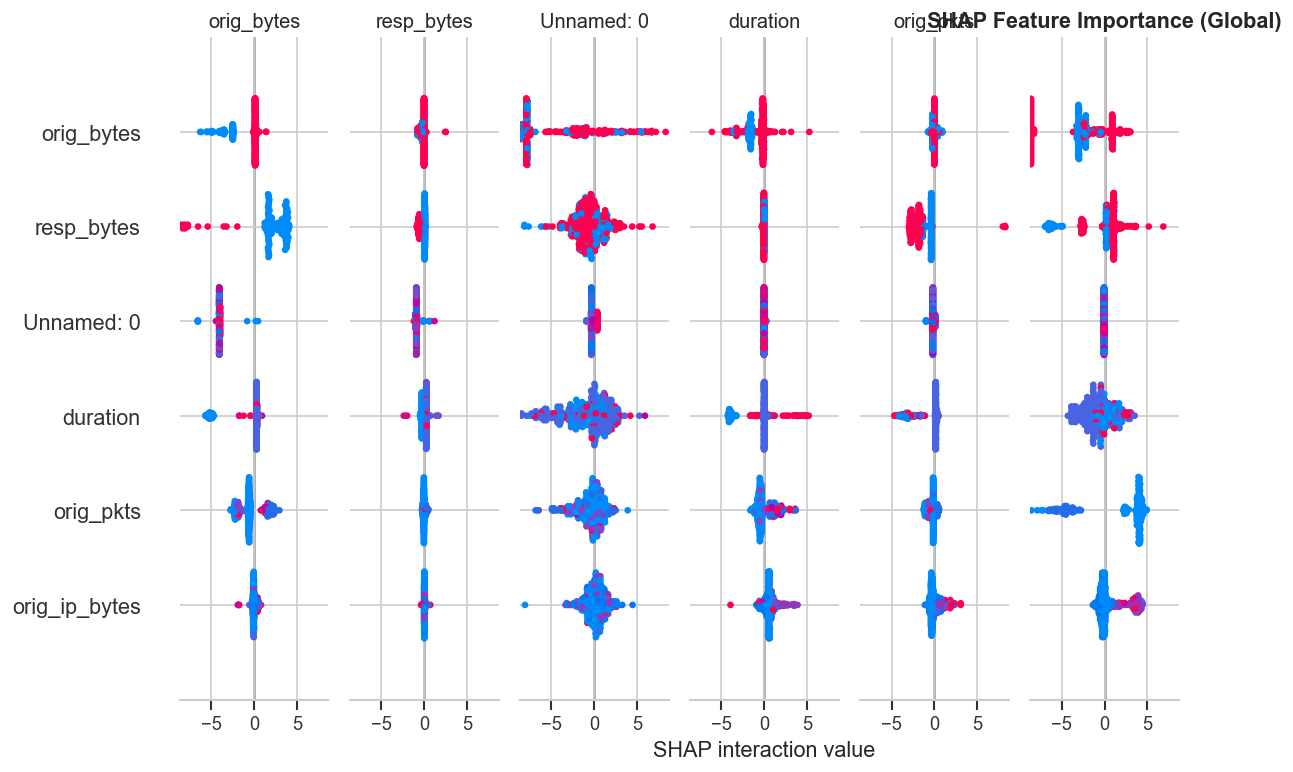

In [19]:
# SHAP Summary Plot (global feature importance)
plt.figure(figsize=(10, 7))
if isinstance(shap_values, list):  # multiclass
    shap.summary_plot(shap_values[0], X_test_df, plot_type='bar',
                      feature_names=selected_features, show=False)
else:
    shap.summary_plot(shap_values, X_test_df, feature_names=selected_features, show=False)
plt.title('SHAP Feature Importance (Global)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 1200x840 with 0 Axes>

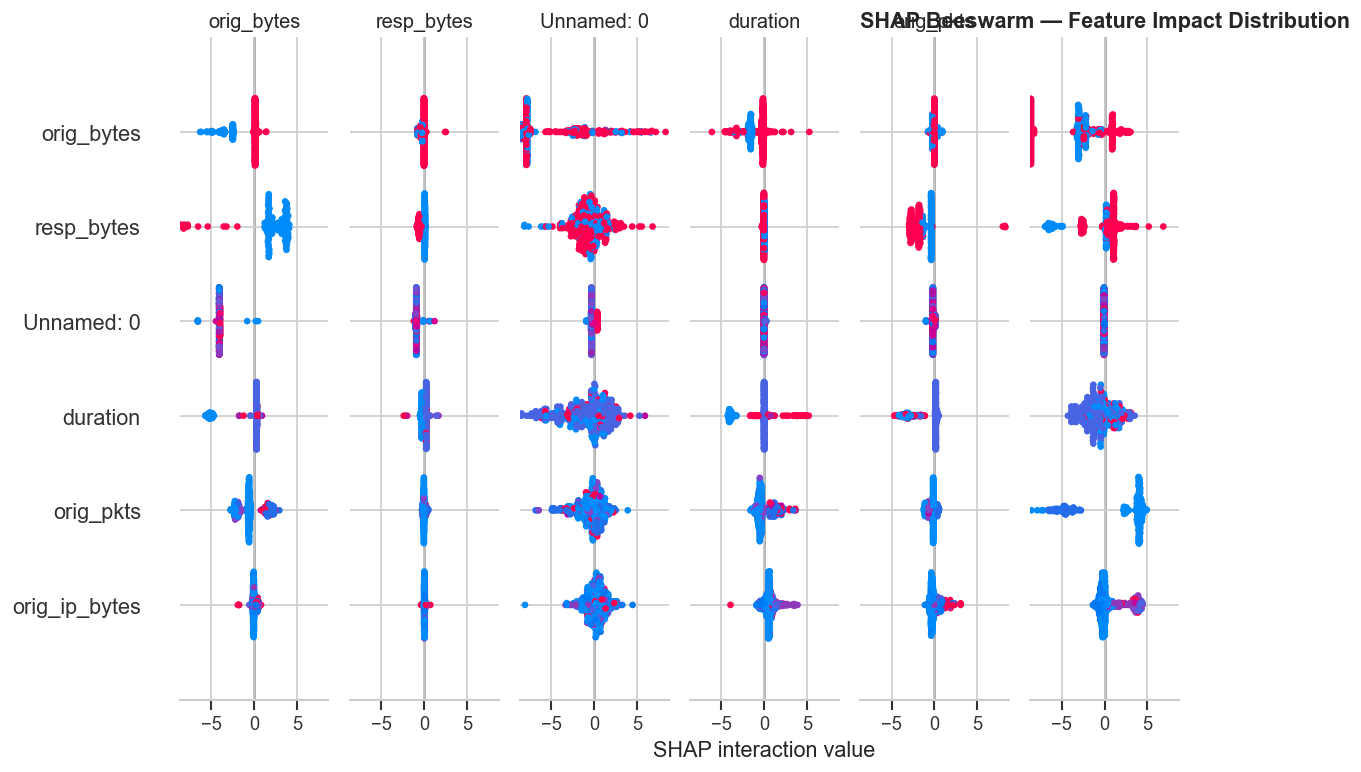

In [20]:
# SHAP Beeswarm plot (feature impact distribution)
if isinstance(shap_values, list):
    shap_vals_plot = shap_values[0]
else:
    shap_vals_plot = shap_values

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_plot, X_test_df, feature_names=selected_features, show=False)
plt.title('SHAP Beeswarm — Feature Impact Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Correlation Heatmap of Selected Features

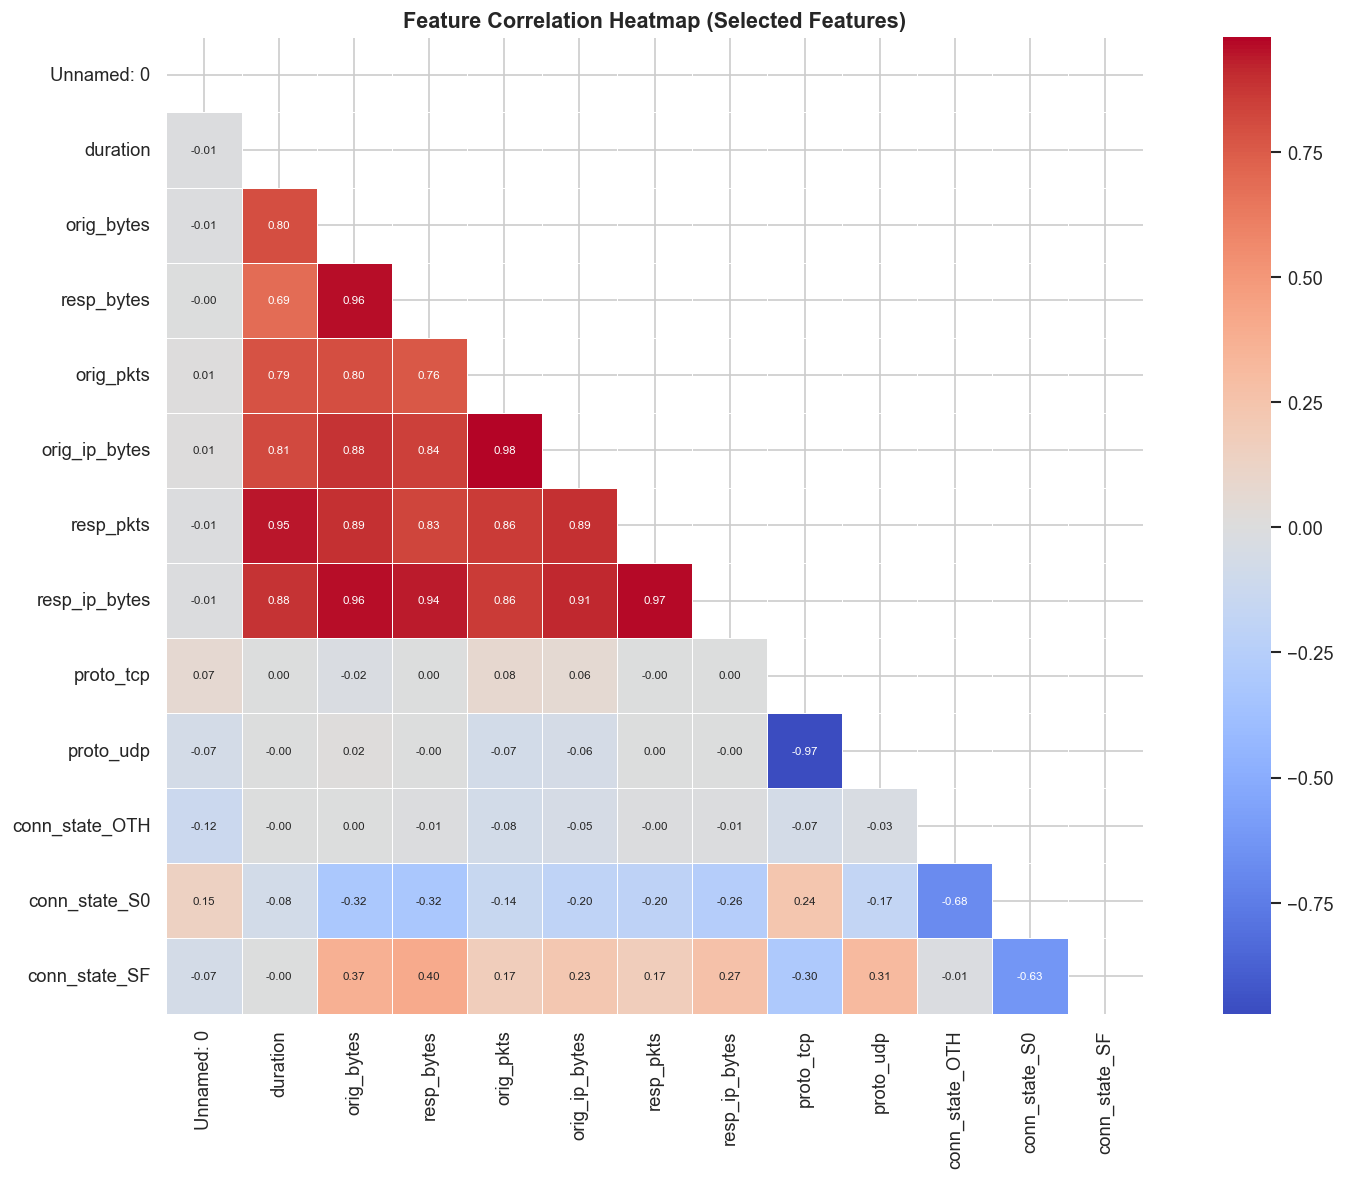

In [21]:
plt.figure(figsize=(14, 10))
corr_matrix = pd.DataFrame(X_train_scaled[:5000], columns=selected_features).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap (Selected Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Summary Report

In [22]:
print('='*65)
print('              FINAL PROJECT SUMMARY REPORT')
print('='*65)
print(f'Dataset       : iot23_combined.csv')
print(f'Sample Size   : {df_sample.shape[0]:,} (stratified from {df.shape[0]:,})')
print(f'Features Used : {len(selected_features)} (after variance + MI selection)')
print(f'SMOTE Applied : Yes (balanced training set)')
print(f'Best Model    : {best_model_name}')
print(f'Accuracy      : {results[best_model_name]["accuracy"]:.4f}')
print(f'F1-Macro      : {results[best_model_name]["f1_macro"]:.4f}')
print(f'MCC           : {results[best_model_name]["mcc"]:.4f}')
print(f"Cohen's Kappa : {results[best_model_name]['kappa']:.4f}")
print('='*65)
print()
print('📁 All models evaluated:')
print(metrics_df[['Model','Accuracy','F1-Macro','MCC']].round(4).to_string(index=False))

              FINAL PROJECT SUMMARY REPORT
Dataset       : iot23_combined.csv
Sample Size   : 14,994 (stratified from 1,048,575)
Features Used : 13 (after variance + MI selection)
SMOTE Applied : Yes (balanced training set)
Best Model    : XGBoost (Tuned)
Accuracy      : 0.5805
F1-Macro      : 0.5902
MCC           : 0.4704
Cohen's Kappa : 0.4185

📁 All models evaluated:
          Model  Accuracy  F1-Macro    MCC
XGBoost (Tuned)    0.5805    0.5902 0.4704
       LightGBM    0.5712    0.5798 0.4583
  Random Forest    0.5258    0.5471 0.4565
 MLP Neural Net    0.4515    0.5089 0.3976
       AdaBoost    0.4288    0.4671 0.3647
      SVM (RBF)    0.4311    0.4479 0.2610


In [23]:
import pickle

# Save the best model as pkl file
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f'✅ Model saved as best_model.pkl')
print(f'Model: {best_model_name}')


✅ Model saved as best_model.pkl
Model: XGBoost (Tuned)
